# 불완전 시계열

### log 변환

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt

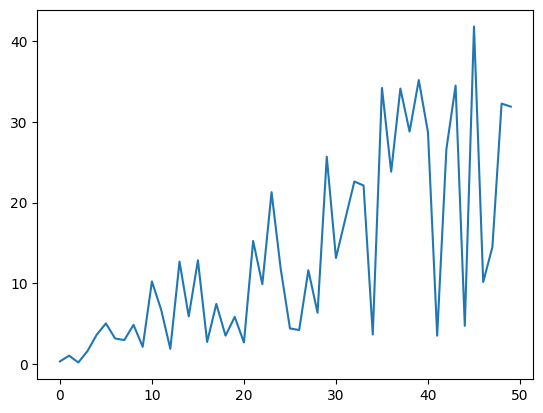

In [2]:
list_a = np.random.rand(50) # 50개의 시계열 데이터 생성
list_a = [(idx+1) * val for idx, val in enumerate(list_a)] # 추세 추가
plt.plot(list_a)
plt.show()

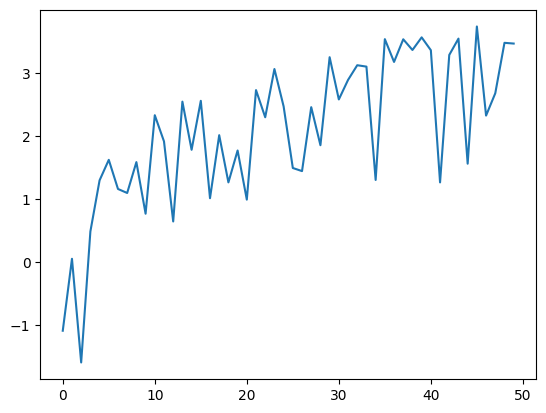

In [3]:
# 로그 변환
list_a = np.log(list_a)
plt.plot(list_a)
plt.show()

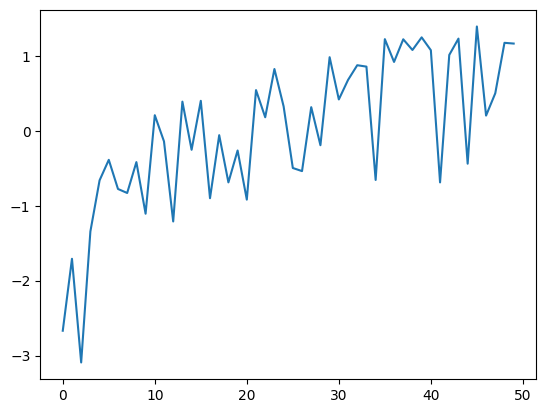

In [4]:
from sklearn import preprocessing

list_a = preprocessing.scale(list_a)
plt.plot(list_a)
plt.show()

### 차분

In [7]:
import numpy as np

list_a = [1,2,3,4,5]
print(list_a)
print(np.diff(list_a))

[1, 2, 3, 4, 5]
[1 1 1 1]


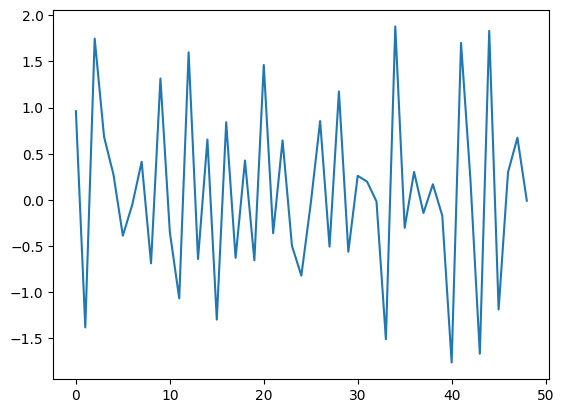

In [5]:
list_a = np.diff(list_a)
plt.plot(list_a)
plt.show()

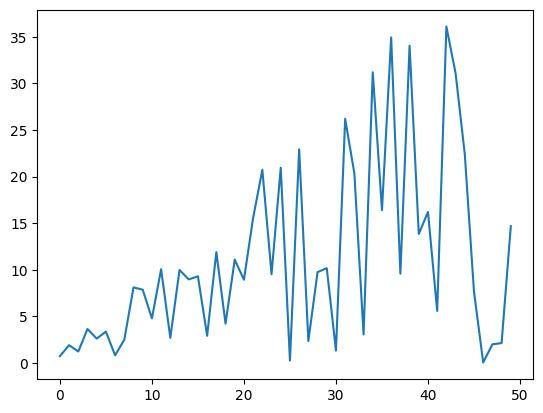

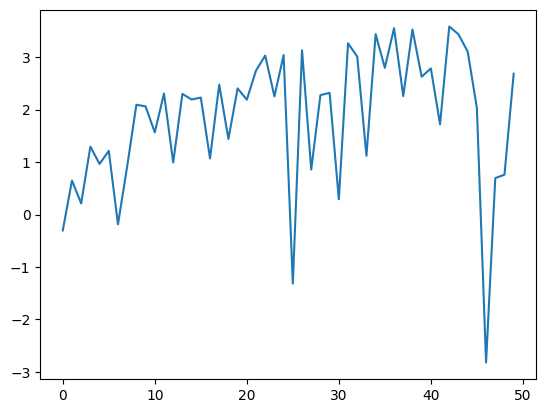

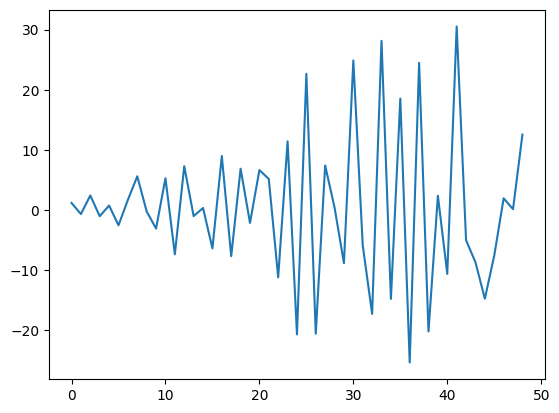

In [7]:
list_a = np.random.rand(50) # 50개의 시계열 데이터 생성
list_a = [(idx+1) * val for idx, val in enumerate(list_a)] # 추세 추가
plt.plot(list_a)
plt.show()

# 로그 변환
list_b = np.log(list_a)
plt.plot(list_b)
plt.show()

# 차분
list_c = np.diff(list_a)
plt.plot(list_c)
plt.show()

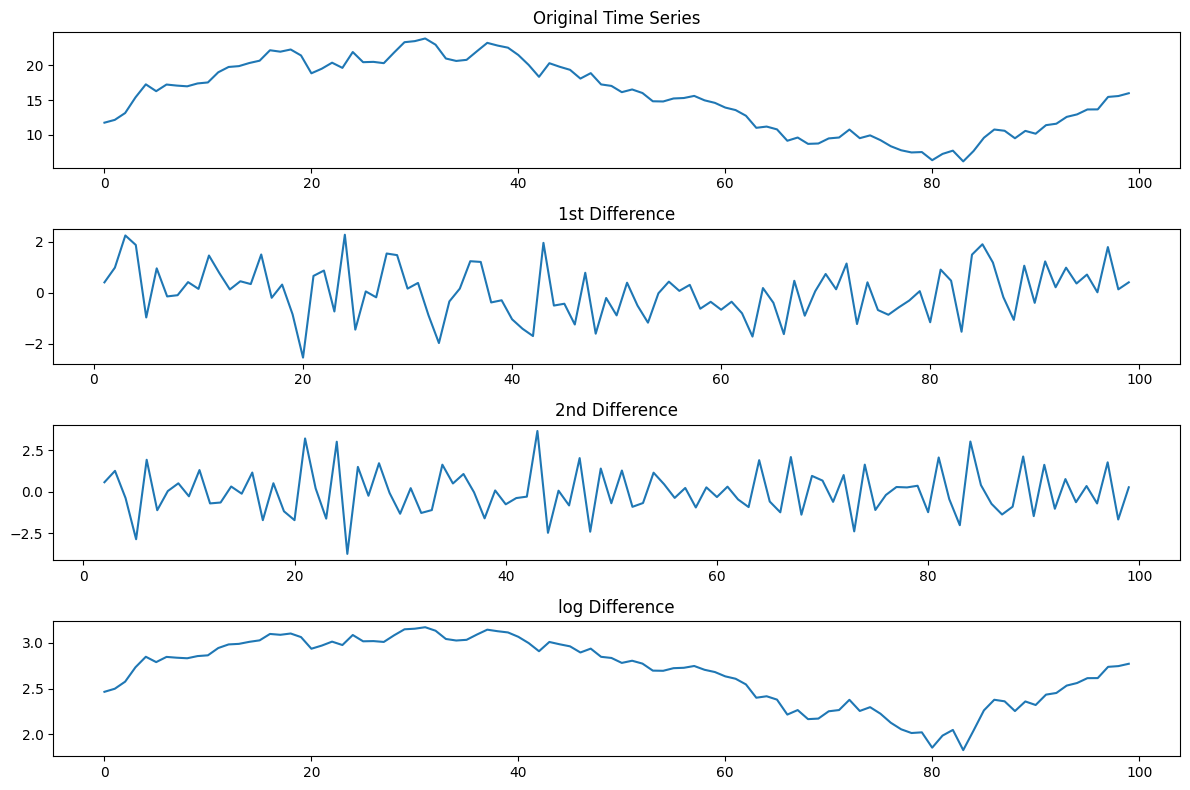

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt

# 데이터 생성
np.random.seed(0)
n = 100
data = np.cumsum(np.random.randn(n)) + 10
time_series = pd.Series(data)

# 1차 차분
diff_1 = time_series.diff()

# 2차 차분
diff_2 = diff_1.diff()

# 로그 변환
diff_3 = np.log(time_series)

plt.figure(figsize=(12,8))
plt.subplot(4,1,1)
plt.plot(time_series)
plt.title('Original Time Series')

plt.subplot(4,1,2)
plt.plot(diff_1)
plt.title('1st Difference')

plt.subplot(4,1,3)
plt.plot(diff_2)
plt.title('2nd Difference')

plt.subplot(4,1,4)
plt.plot(diff_3)
plt.title('log Difference')

plt.tight_layout()
plt.show()

## 이동평균 평활법

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [124]:
df = pd.read_csv('daily-total-female-births-CA.csv')
df.head()

,date,births
0,1959-01-01,35
1,1959-01-02,32
2,1959-01-03,30
3,1959-01-04,31
4,1959-01-05,44


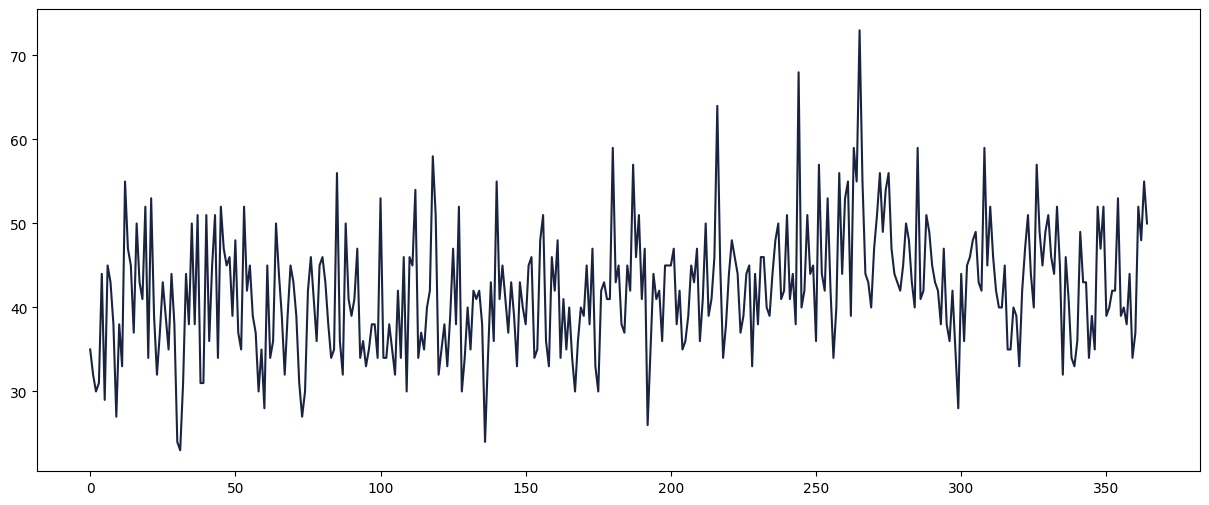

In [125]:
df.births.plot(figsize=(15,6))
plt.show()

### 단순 이동 평활법

In [126]:
def SMA(array, window): # 단순 이동 평활법
    array = np.array(array)
    assert array.ndim == 1, "1차원 array만 입력할 수 있습니다."
    n = len(array)

    result = np.empty(n)
    result[:] = np.nan

    ma = []
    for i in range(0, n-window+1):
        m = np.mean(array[i:i+window])
        ma.append(m)

    result[window-1:] = ma
    return np.array(result)

In [127]:
timestamp = df.births
timestamp

0      35
1      32
2      30
3      31
4      44
       ..
360    37
361    52
362    48
363    55
364    50
Name: births, Length: 365, dtype: int64

[39.7  40.75 41.2  41.25 40.9  41.6  41.3  40.9  41.2  41.75 41.05 40.55
 39.35 39.2  38.85 39.5  38.9  39.3  38.8  37.75 38.6  37.75 38.05 39.
 38.85 39.3  39.7  40.2  40.3  40.35 41.55 42.25 42.45 42.85 43.05 42.8
 42.85 42.15 42.1  42.3  41.15 41.6  41.05 40.3  41.1  40.7  40.3  39.65
 39.3  39.6  39.35 39.45 39.25 38.   37.4  37.25 37.6  37.8  38.1  38.6
 39.5  39.4  39.6  39.5  38.75 39.35 39.2  39.2  39.75 39.55 39.35 39.45
 40.25 40.6  40.9  40.45 39.9  39.75 39.85 39.3  39.65 39.2  39.   39.2
 39.2  38.   38.3  38.4  38.2  37.65 38.   38.2  38.55 38.55 38.6  38.7
 38.95 39.15 40.15 41.   39.95 40.   40.2  39.95 40.15 40.9  40.7  41.6
 40.8  41.   40.7  40.2  39.6  39.95 40.2  40.35 39.55 39.15 38.4  37.65
 38.8  39.1  39.45 39.85 39.75 39.55 39.6  38.65 39.3  39.6  39.5  40.
 40.2  39.85 39.5  40.   41.35 41.45 40.95 41.45 40.8  41.15 40.6  40.6
 40.5  40.35 40.1  39.95 39.6  39.6  39.65 39.65 39.25 39.9  39.8  38.9
 38.45 38.8  39.2  38.95 39.8  39.55 40.1  39.95 40.05 40.3  4

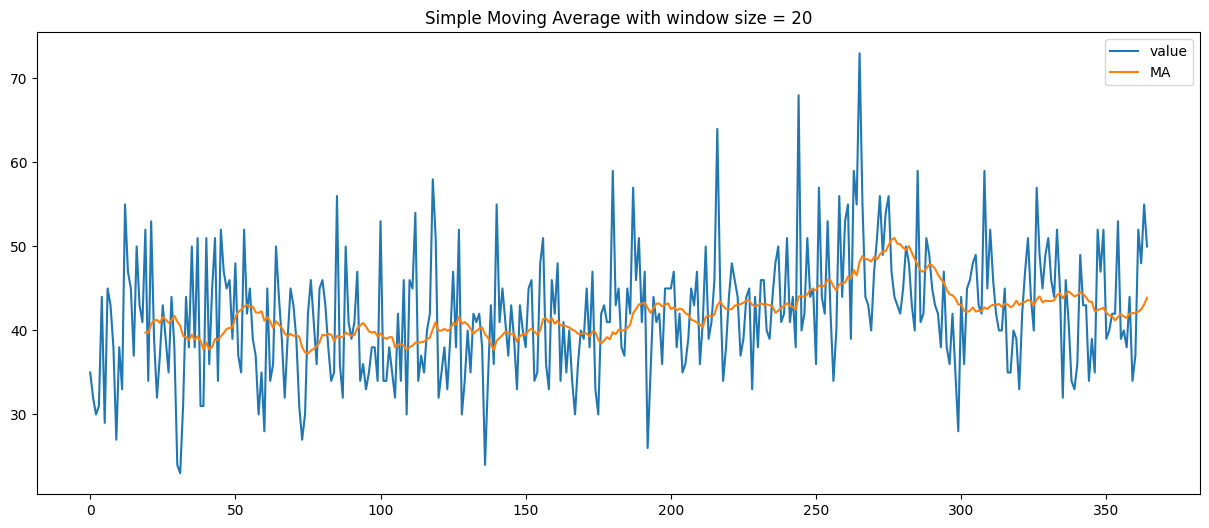

In [25]:
window = 20
sma = SMA(timestamp, window)
print(sma[20:])

timestamp.plot(figsize=(15,6))
plt.plot(sma)
plt.legend(['value', 'MA'])
plt.title("Simple Moving Average with window size = {}".format(window))
plt.show()

### 누적 이동 평균

In [11]:
def CMA(array): # 누적 이동 평균
    array = np.array(array)
    assert array.ndim == 1, "1차원 array만 입력할 수 있습니다."
    n = len(array)

    result = []
    for i in range(n):
        m = np.mean(array[0:i+1])
        result.append(m)

    return result

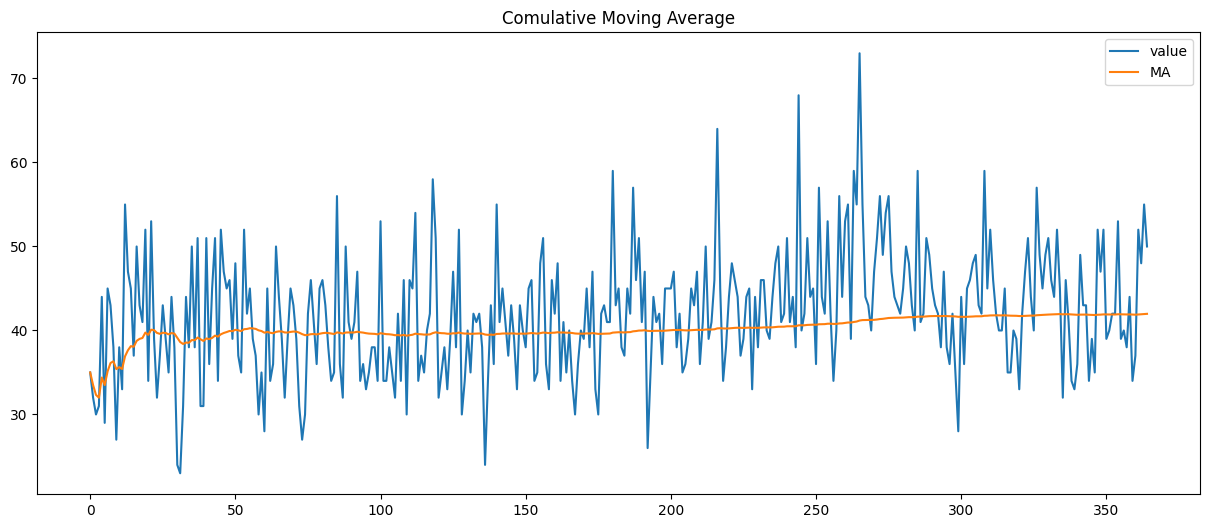

In [12]:
cma = CMA(timestamp)

timestamp.plot(figsize=(15,6))
plt.plot(cma)
plt.legend(['value', 'MA'])
plt.title("Comulative Moving Average")
plt.show()

### 가중 이동 평균

In [13]:
def WMA(array, window): # 가중 이동 평균
    array = np.array(array)
    assert array.ndim == 1, "1차원 array만 입력할 수 있습니다."
    n = len(array)

    result = np.empty(n)
    result[:] = np.nan

    weight = np.arange(1, window+1, 1) # 가중치 설정

    ma = []
    for i in range(0, n-window+1):
        A = np.sum(weight * array[i:i+window])
        B = np.sum(weight)
        m = A / B
        ma.append(m)

    result[window-1:] = ma
    return np.array(result)

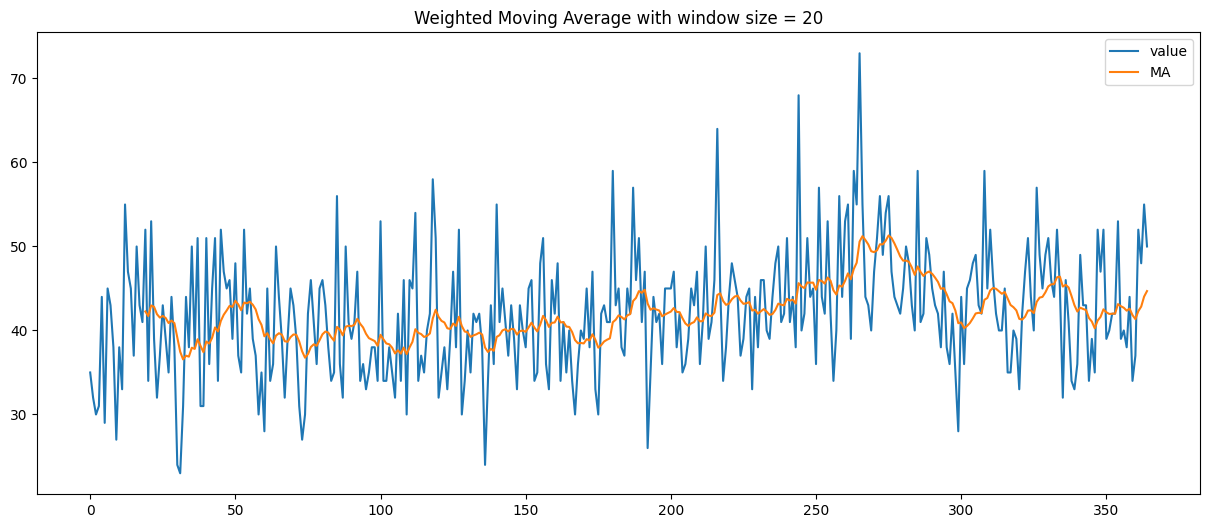

In [14]:
wma = WMA(timestamp, window)

timestamp.plot(figsize=(15,6))
plt.plot(wma)
plt.legend(['value', 'MA'])
plt.title("Weighted Moving Average with window size = {}".format(window))
plt.show()

### 지수 가중 이동 평균

In [128]:
def EWMA(array, alpha): # 지수 가중 이동 평균
    array = np.array(array)
    assert array.ndim == 1, "1차원 array만 입력할 수 있습니다."
    n = len(array)

    ma = []
    ma.append(array[0]) # 1번째 지수가중이동평균 = 1번째 데이터 값
    for i in range(1, n):
        # n번째 지수가중이동평균 = a * 현재 데이터값 + (1 - a) * (n-1번째 지수가중평균) 
        # alpha값이 커지면 현재 데이터의 비중이 커짐, 아니면 최근 데이터의 비중이 커짐
        m = alpha * array[i] + (1-alpha) * ma[-1]
        ma.append(m)

    return np.array(ma)

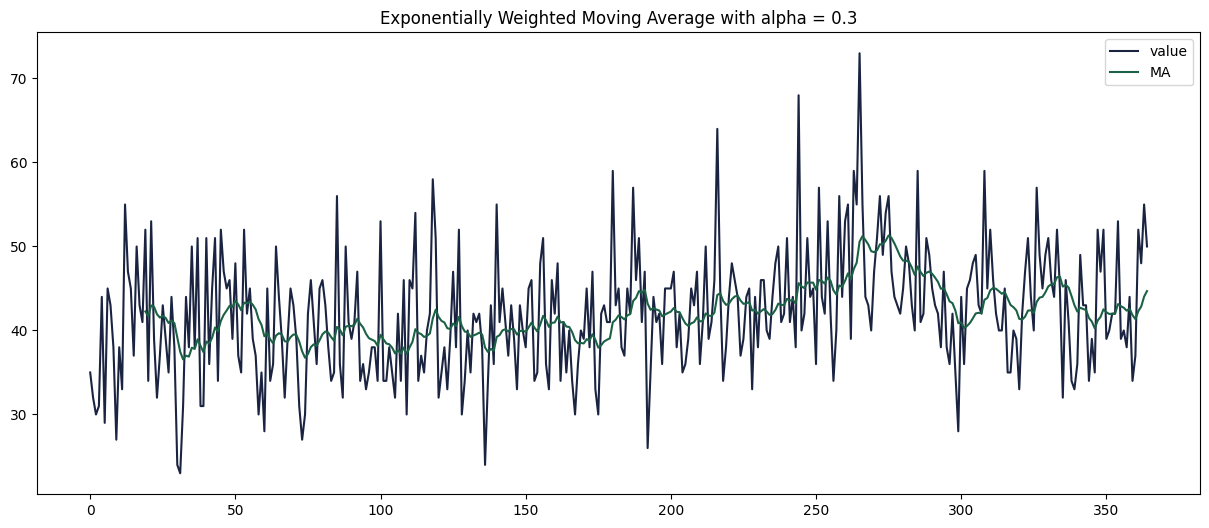

In [129]:
alpha = 0.3
ewma = EWMA(timestamp, alpha)

timestamp.plot(figsize=(15,6))
plt.plot(wma)
plt.legend(['value', 'MA'])
plt.title("Exponentially Weighted Moving Average with alpha = {}".format(alpha))
plt.show()

## pip install yfinance

In [28]:
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import date
from statsmodels.tsa.holtwinters import (ExponentialSmoothing,SimpleExpSmoothing, Holt)

In [29]:
plt.set_cmap('cubehelix')
sns.set_palette('cubehelix')
COLORS = [plt.cm.cubehelix(x) for x in [0.1, 0.3, 0.5, 0.7]]

<Figure size 640x480 with 0 Axes>

In [31]:
df = yf.download('AAPL',
                start = '2023-01-01',
                end = '2023-12-31',
                progress=False)
df.head(2Q

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
2023-01-03,122.982727,128.715425,122.097746,128.105777,112117500
2023-01-04,124.251175,126.512793,122.992538,124.772329,89113600


In [32]:
moving_average = df['Close'].rolling(window=5).mean() # rolling(window=num).mean() >> num크기의 이동평균 구하는 함수
moving_average

Ticker,AAPL
2023-01-03,NaN
2023-01-04,NaN
2023-01-05,NaN
2023-01-06,NaN
2023-01-09,125.120436
...,...
2023-12-22,193.003326
2023-12-26,192.441672
2023-12-27,191.692151
2023-12-28,191.444949


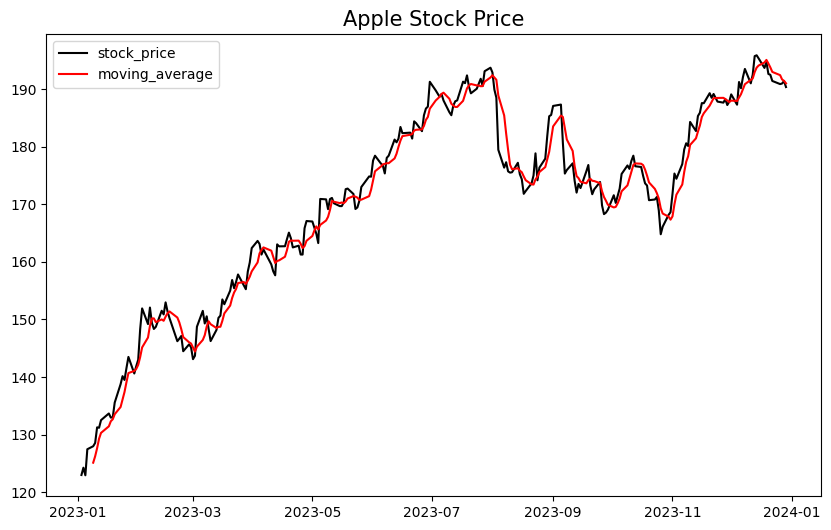

In [33]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize =(10,6))
fig.set_facecolor('white')
plt.plot(df.index, df.Close, color = 'k', label='stock_price')
plt.plot(moving_average.index, moving_average, color='red', label='moving_average')
plt.legend()
plt.title('Apple Stock Price', fontsize=15)
plt.show()

In [44]:
df = pd.read_csv("./AAPL.csv")
df.head(2)

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100323,469033600
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.095089,175884800


In [45]:
df["Date"] = pd.DatetimeIndex(df["Date"])
df = df.set_index(keys="Date")
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100323,469033600
1980-12-15,0.122210,0.122210,0.121652,0.121652,0.095089,175884800
1980-12-16,0.113281,0.113281,0.112723,0.112723,0.088110,105728000
1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090291,86441600
1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092908,73449600


In [46]:
aapl = df.resample('ME').last().rename(columns={"Adj Close" : 'adj_close'}).adj_close
aapl.head()

Date
1980-12-31    0.119080
1981-01-31    0.098578
1981-02-28    0.092472
1981-03-31    0.085493
1981-04-30    0.099015
Freq: ME, Name: adj_close, dtype: float64

In [47]:
aapl_indices = aapl.index >= '2015-01-01'
aapl_2015 = aapl[aapl_indices]
aapl_2015.head()

Date
2015-01-31    26.484514
2015-02-28    29.153534
2015-03-31    28.238945
2015-04-30    28.402336
2015-05-31    29.690079
Freq: ME, Name: adj_close, dtype: float64

In [48]:
train_indices = aapl_2015.index < '2022-01-01'
aapl_train = aapl_2015[train_indices]
aapl_test = aapl_2015[~train_indices]

In [49]:
train_length = len(aapl_train)
test_length = len(aapl_test)
print(train_length, test_length)

84 3


In [55]:
ses_1 = SimpleExpSmoothing(aapl_train).fit(smoothing_level=0.2)
ses_forecast_1 = ses_1.forecast(test_length)

ses_2 = SimpleExpSmoothing(aapl_train).fit(smoothing_level=0.5)
ses_forecast_2 = ses_2.forecast(test_length)

ses_3 = SimpleExpSmoothing(aapl_train).fit()
alpha = ses_3.model.params["smoothing_level"]
ses_forecast_3 = ses_3.forecast(test_length)

C:\Project\Python_Source\AI01\.venv\Lib\site-packages\pandas\util\_decorators.py:220: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Project\Python_Source\AI01\.venv\Lib\site-packages\pandas\util\_decorators.py:220: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)


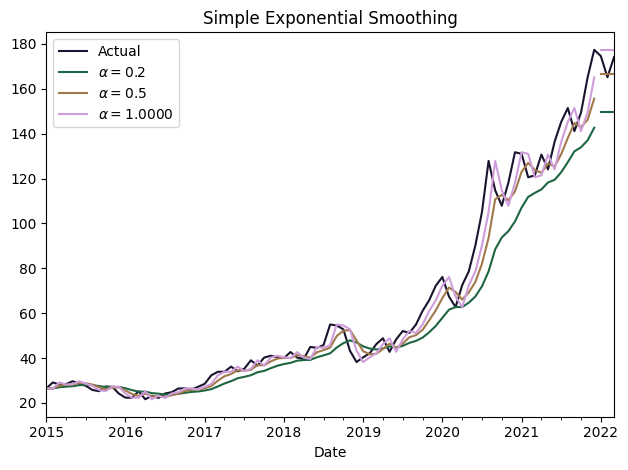

In [58]:
aapl_2015.plot(color=COLORS[0],
               title='Simple Exponential Smoothing',
               label = 'Actual',
               legend=True)

ses_forecast_1.plot(color=COLORS[1], legend=True, label=r"$\alpha=0.2$")
ses_1.fittedvalues.plot(color=COLORS[1])

ses_forecast_2.plot(color=COLORS[2], legend=True, label=r"$\alpha=0.5$")
ses_2.fittedvalues.plot(color=COLORS[2])

ses_forecast_3.plot(color=COLORS[3], legend=True, label=r"$\alpha={0:.4f}$".format(alpha))
ses_3.fittedvalues.plot(color=COLORS[3])

plt.tight_layout()
plt.show()

In [67]:
import pprint
import yfinance as yf

ticker = yf.Ticker('AAPL')
pprint.pprint(ticker.info)

{'52WeekChange': 0.54248035,
 'SandP52WeekChange': 0.26208222,
 'address1': 'One Apple Park Way',
 'allTimeHigh': 311.4,
 'allTimeLow': 0.049107,
 'ask': 309.89,
 'askSize': 5,
 'auditRisk': 2,
 'averageAnalystRating': '2.0 - Buy',
 'averageDailyVolume10Day': 43241680,
 'averageDailyVolume3Month': 43882808,
 'averageVolume': 43882808,
 'averageVolume10days': 43241680,
 'beta': 1.065,
 'bid': 308.55,
 'bidSize': 5,
 'boardRisk': 1,
 'bookValue': 7.26,
 'city': 'Cupertino',
 'companyOfficers': [{'age': 64,
                      'exercisedValue': 0,
                      'fiscalYear': 2025,
                      'maxAge': 1,
                      'name': 'Mr. Timothy D. Cook',
                      'title': 'CEO & Director',
                      'totalPay': 16759518,
                      'unexercisedValue': 0,
                      'yearBorn': 1961},
                     {'age': 53,
                      'exercisedValue': 0,
                      'fiscalYear': 2025,
                    

In [69]:
# Period : ['1d', '5d', '1mo', ' 3mo', '6mo', '1y', '2y', '5y', '10y', 'ytd', 'max']
print(ticker.history(period='5d'))

                                 Open        High         Low       Close  \
Date                                                                        
2026-05-18 00:00:00-04:00  300.239990  300.660004  294.910004  297.839996   
2026-05-19 00:00:00-04:00  296.970001  300.510010  296.350006  298.970001   
2026-05-20 00:00:00-04:00  298.179993  302.799988  298.079987  302.250000   
2026-05-21 00:00:00-04:00  301.059998  305.540009  300.399994  304.989990   
2026-05-22 00:00:00-04:00  306.119995  311.399994  305.839996  308.820007   

                             Volume  Dividends  Stock Splits  
Date                                                          
2026-05-18 00:00:00-04:00  34483000        0.0           0.0  
2026-05-19 00:00:00-04:00  42243600        0.0           0.0  
2026-05-20 00:00:00-04:00  38229800        0.0           0.0  
2026-05-21 00:00:00-04:00  42965100        0.0           0.0  
2026-05-22 00:00:00-04:00  43627900        0.0           0.0  


In [68]:
print(ticker.income_stmt)

                                                      2025-09-30  \
Tax Effect Of Unusual Items                         0.000000e+00   
Tax Rate For Calcs                                  1.560000e-01   
Normalized EBITDA                                   1.447480e+11   
Net Income From Continuing Operation Net Minori...  1.120100e+11   
Reconciled Depreciation                             1.169800e+10   
Reconciled Cost Of Revenue                          2.209600e+11   
EBITDA                                              1.447480e+11   
EBIT                                                1.330500e+11   
Net Interest Income                                          NaN   
Interest Expense                                             NaN   
Interest Income                                              NaN   
Normalized Income                                   1.120100e+11   
Net Income From Continuing And Discontinued Ope...  1.120100e+11   
Total Expenses                                  

In [70]:
print(ticker.recommendations)

  period  strongBuy  buy  hold  sell  strongSell
0     0m          7   23    16     1           1
1    -1m          7   25    14     1           1
2    -2m          6   25    15     1           1
3    -3m          5   25    16     1           1


In [71]:
ticker = yf.Ticker('SNDK')

In [72]:
ticker.recommendations

,period,strongBuy,buy,hold,sell,strongSell
0,0m,2,15,4,0,1
1,-1m,2,14,4,0,1
2,-2m,2,12,6,0,0
3,-3m,2,12,6,0,0


## 판다스의 interpolate

In [60]:
import pandas as pd
import numpy as np

data = {'A' : [1, 2, np.nan, 4, 5],
        'B' : [5, np.nan, np.nan, 8, 9],
        'C' : [9,10,11,12,13]}

df = pd.DataFrame(data)
df

,A,B,C
0,1.0,5.0,9
1,2.0,NaN,10
2,NaN,NaN,11
3,4.0,8.0,12
4,5.0,9.0,13


In [62]:
df_interpolated = df.interpolate(method = 'linear') # method = 'linear'
df_interpolated

,A,B,C
0,1.0,5.0,9
1,2.0,6.0,10
2,3.0,7.0,11
3,4.0,8.0,12
4,5.0,9.0,13


In [63]:
df_interpolated2 = df['A'].interpolate()
df_interpolated2

0    1.0
1    2.0
2    3.0
3    4.0
4    5.0
Name: A, dtype: float64

In [64]:
df_interpolated = df.interpolate(method='polynomial', order=1)
df_interpolated

,A,B,C
0,1.0,5.0,9
1,2.0,6.0,10
2,3.0,7.0,11
3,4.0,8.0,12
4,5.0,9.0,13


In [65]:
df_interpolated = df.interpolate(method='polynomial', order=2)
df_interpolated

,A,B,C
0,1.0,5.0,9
1,2.0,6.0,10
2,3.0,7.0,11
3,4.0,8.0,12
4,5.0,9.0,13


In [66]:
df_interpolated2 = df['A'].interpolate(method='spline', order=3)
df_interpolated2

0    1.0
1    2.0
2    3.0
3    4.0
4    5.0
Name: A, dtype: float64

## prophet

### Prophet에서 사용하는 주요 메소드들
- fit(df)
    - Prophet 모델에 데이터를 적합시키는 메소드다. df는 예측할 시계열 데이터로, ds(날짜)와 y(값)를 포함하는 데이터프레임이다.
- predict(future)
    - 주어진 미래 데이터를 기반으로 예측을 수행하는 메소드다. future는 예측할 기간에 대한 날짜 정보를 포함하는 데이터프레임으로, Prophet은 이를 사용해 미래의 값을 예측한다.
- make_future_dataframe(periods=n)
    - 미래 예측을 위한 날짜 데이터프레임을 생성한다. n은 예측할 기간의 길이를 나타내며, 예측하고자 하는 날짜 범위에 해당한다.
- add_seasonality(name, period, fourier_order)
    - 사용자 정의 계절성을 추가하는 메소드입니다. name은 계절성의 이름, period는 계절성의 주기(예: 365.25), fourier_order는 푸리에 급수의 차수를 지정한다. 이를 통해 기본 제공되는 연간, 주간 계절성 외에 추가적인 주기 패턴을 모델에 반영할 수 있다.
- plot(fcst)
    - Prophet 모델의 예측 결과를 시각화하는 메소드다. 예측된 값(fcst)을 시각적으로 표현하며, 추세, 계절성, 변화점 등을 직관적으로 확인할 수 있다.
- plot_components(fcst)
    - Prophet 모델의 각 성분(추세, 계절성, 휴일 효과 등)을 분해하여 시각화하는 메소드다. 이 메소드를 통해 각 성분이 시계열에 어떻게 기여하는지 확인할 수 있다.

In [73]:
from prophet import Prophet # pip install Prophet
import pandas as pd

Importing plotly failed. Interactive plots will not work.


14:31:27 - cmdstanpy - INFO - Chain [1] start processing
14:31:28 - cmdstanpy - INFO - Chain [1] done processing


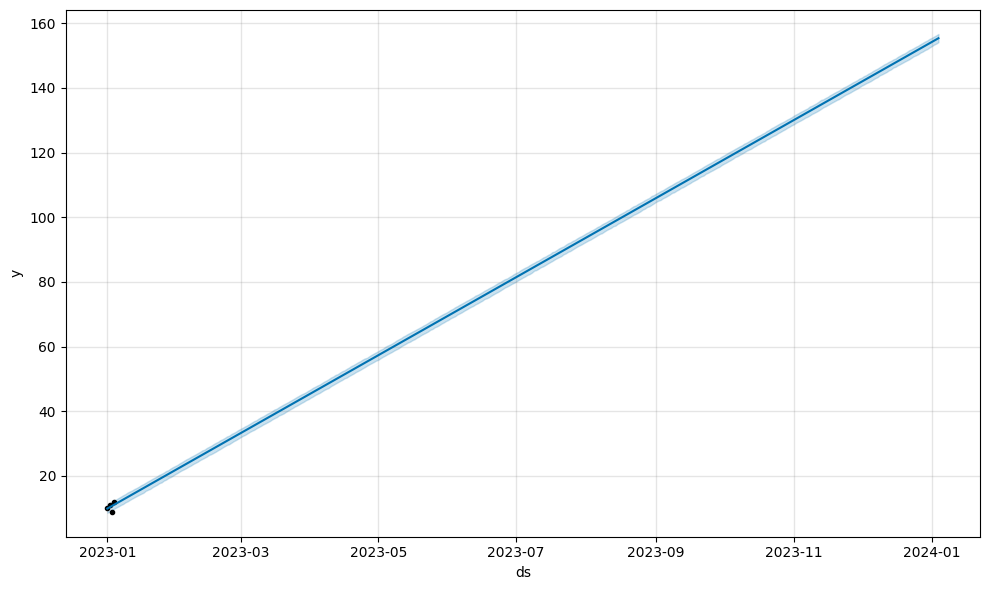

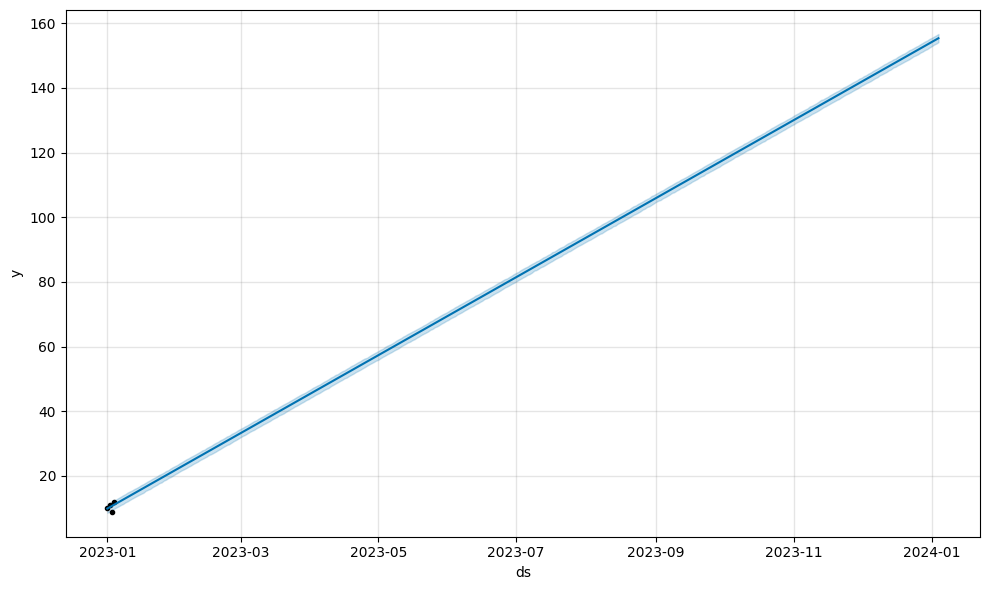

In [74]:
df = pd.DataFrame({
    'ds' : ['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04'], # 시간변수
    'y' : [10,11,9,12] # 예측할 값(타겟)
})
df['ds'] = pd.to_datetime(df['ds']) # 날짜 자료형 변형

# 모델 선언 및 학습
model = Prophet()
model.fit(df)

future = model.make_future_dataframe(periods=365) # 기존 날짜 데이터 뒤에 추가로 365일치 자동으로 확장하는 함수
forecast = model.predict(future) # 예측값 계산
model.plot(forecast)

In [75]:
forecast.columns

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'additive_terms', 'additive_terms_lower', 'additive_terms_upper',
       'multiplicative_terms', 'multiplicative_terms_lower',
       'multiplicative_terms_upper', 'yhat'],
      dtype='str')

- ds : 날짜 및 시간 정보를 나타내는 열입니다.
- trend : 전반적인 추세를 나타내는 열로, 시간에 따른 데이터의 일반적인 증감 추이를 나타냅니다.
- yhat : 전체 예측 최종값입니다.
- yhat_lower : 예측 값의 최소 하한선(lower bound)을 나타내는 열입니다.
- yhat_upper : 예측 값의 최대 상한선(upper bound)을 나타내는 열입니다.
- trend_lower, trend_upper : 추세의 최소 및 최대 경계를 나타내는 열입니다.
- additive_terms : 일일, 주간, 연간 등의 추가적인 성분을 나타내는 열입니다.
- additive_terms_lower, additive_terms_upper : 추가적인 성분의 최소 및 최대 경계를 나타내는 열입니다.
- daily, daily_lower, daily_upper: 일일 성분에 대한 값과 그 최소 및 최대 경계를 나타내는 열입니다.
- weekly, weekly_lower, weekly_upper: 주간 성분에 대한 값과 그 최소 및 최대 경계를 나타내는 열입니다.
- yearly, yearly_lower, yearly_upper: 연간 성분에 대한 값과 그 최소 및 최대 경계를 나타내는 열입니다.
- multiplicative_terms, multiplicative_terms_lower, multiplicative_terms_upper : 곱셈 항(multiplicative term)에 대한 값과 그 최소 및 최대 경계를 나타내는 열입니다.

In [76]:
import pandas as pd

df = pd.read_csv('./AAPL.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100323,469033600
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.095089,175884800
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.088110,105728000
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090291,86441600
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092908,73449600


In [77]:
df['ds'] = df['Date']
df['y'] = df['Close']

In [79]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10409 entries, 0 to 10408
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       10409 non-null  str    
 1   Open       10409 non-null  float64
 2   High       10409 non-null  float64
 3   Low        10409 non-null  float64
 4   Close      10409 non-null  float64
 5   Adj Close  10409 non-null  float64
 6   Volume     10409 non-null  int64  
 7   ds         10409 non-null  str    
 8   y          10409 non-null  float64
dtypes: float64(6), int64(1), str(2)
memory usage: 732.0 KB


In [80]:
data = df[['ds', 'y']]
data = data[-1000:]
data.head()

,ds,y
9409,2018-04-06,42.095001
9410,2018-04-09,42.512501
9411,2018-04-10,43.312500
9412,2018-04-11,43.110001
9413,2018-04-12,43.535000


In [82]:
from prophet import Prophet

prophet_m = Prophet().fit(data)

14:42:39 - cmdstanpy - INFO - Chain [1] start processing
14:42:39 - cmdstanpy - INFO - Chain [1] done processing


In [85]:
data.tail()

,ds,y
10404,2022-03-18,163.979996
10405,2022-03-21,165.380005
10406,2022-03-22,168.820007
10407,2022-03-23,170.210007
10408,2022-03-24,174.070007


In [83]:
future = prophet_m.make_future_dataframe(periods=365)

In [87]:
future.tail()

,ds
1360,2023-03-20
1361,2023-03-21
1362,2023-03-22
1363,2023-03-23
1364,2023-03-24


In [88]:
forecast = prophet_m.predict(future)

In [89]:
forecast[['ds','yhat','yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
1360,2023-03-20,203.237317,151.470903,252.908243
1361,2023-03-21,203.600861,151.727698,251.141447
1362,2023-03-22,203.832267,152.337693,253.192204
1363,2023-03-23,203.787032,152.529221,252.555481
1364,2023-03-24,203.702976,151.743871,252.386364


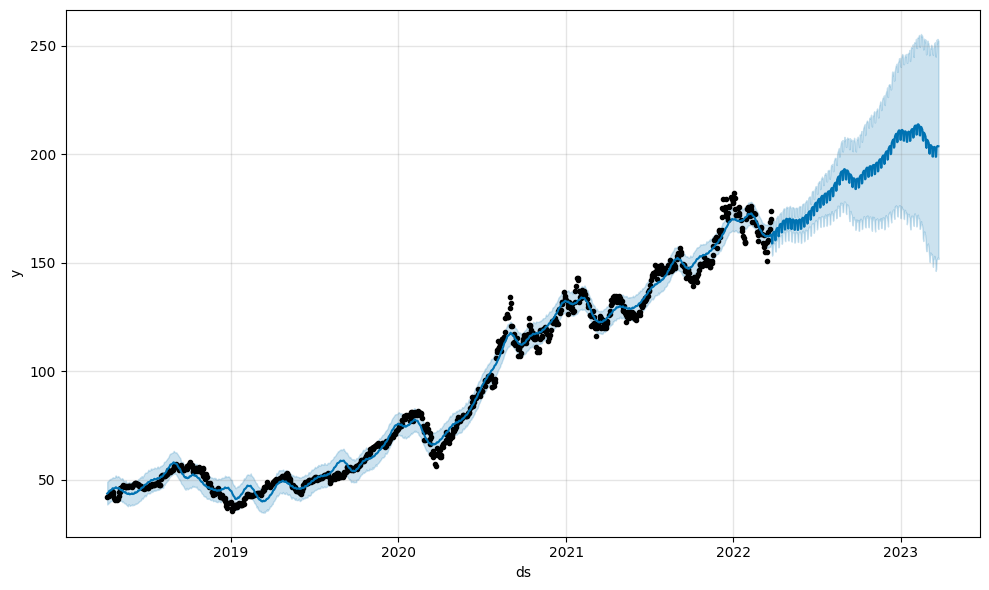

In [92]:
prophet_m.plot(forecast)
plt.show()

### 자동차 판매량 데이터

In [93]:
import pandas as pd

path = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-car-sales.csv'
df = pd.read_csv(path, header=0)
df.head()

,Month,Sales
0,1960-01,6550
1,1960-02,8728
2,1960-03,12026
3,1960-04,14395
4,1960-05,14587


In [94]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Month   108 non-null    str  
 1   Sales   108 non-null    int64
dtypes: int64(1), str(1)
memory usage: 1.8 KB


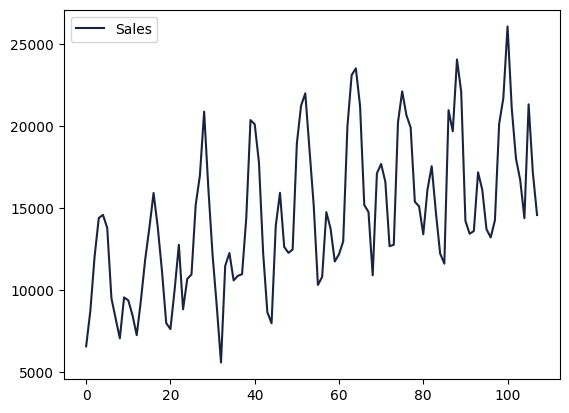

In [95]:
from matplotlib import pyplot

df.plot()
pyplot.show()

In [99]:
df.columns = ['ds', 'y']
df['ds'] = pd.to_datetime(df['ds'])
df.head()

,ds,y
0,1960-01-01,6550
1,1960-02-01,8728
2,1960-03-01,12026
3,1960-04-01,14395
4,1960-05-01,14587


In [100]:
df.tail()

,ds,y
103,1968-08-01,16722
104,1968-09-01,14385
105,1968-10-01,21342
106,1968-11-01,17180
107,1968-12-01,14577


In [101]:
from prophet import Prophet

model = Prophet()
model.fit(df)

15:11:18 - cmdstanpy - INFO - Chain [1] start processing
15:11:18 - cmdstanpy - INFO - Chain [1] done processing


#### In Sample Forecast

In [102]:
last_1year = list()
for i in range(1,13):
    last_1year.append(['1968-%02d' % i])
last_1year = pd.DataFrame(last_1year, columns = ['ds'])
last_1year['ds'] = pd.to_datetime(last_1year['ds'])
last_1year

,ds
0,1968-01-01
1,1968-02-01
2,1968-03-01
3,1968-04-01
4,1968-05-01
5,1968-06-01
6,1968-07-01
7,1968-08-01
8,1968-09-01
9,1968-10-01


In [103]:
forecast = model.predict(last_1year)

In [105]:
forecast.columns

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'additive_terms', 'additive_terms_lower', 'additive_terms_upper',
       'yearly', 'yearly_lower', 'yearly_upper', 'multiplicative_terms',
       'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yhat'],
      dtype='str')

In [109]:
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

          ds          yhat    yhat_lower    yhat_upper
0 1968-01-01  14365.818264  12772.184819  16077.179138
1 1968-02-01  14940.296788  13375.908653  16443.024000
2 1968-03-01  20882.023591  19351.145026  22500.252467
3 1968-04-01  22900.422751  21328.995741  24435.192689
4 1968-05-01  24201.075774  22628.149114  25667.277505


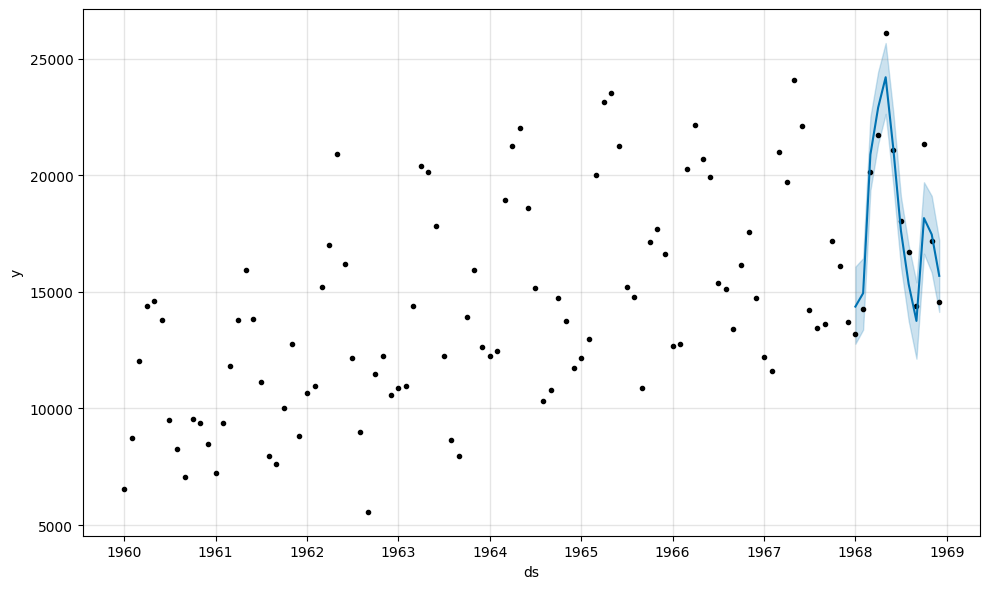

In [110]:
model.plot(forecast)
pyplot.show()

### Out of Sample Forecast

In [112]:
last_1year = list()
for i in range(1,13):
    last_1year.append(['1969-%02d' % i])
last_1year = pd.DataFrame(last_1year, columns = ['ds'])
last_1year['ds'] = pd.to_datetime(last_1year['ds'])
last_1year

,ds
0,1969-01-01
1,1969-02-01
2,1969-03-01
3,1969-04-01
4,1969-05-01
5,1969-06-01
6,1969-07-01
7,1969-08-01
8,1969-09-01
9,1969-10-01


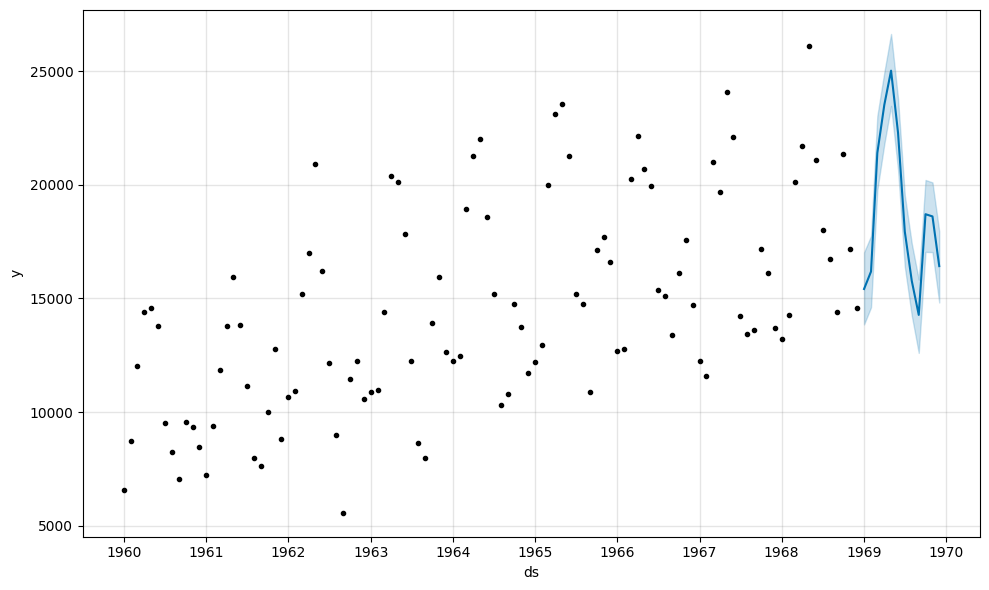

In [113]:
forecast = model.predict(last_1year)
model.plot(forecast)
pyplot.show()

### 모델 평가

In [114]:
train = df.drop(df.index[-12:])
y_true = df['y'][-12:].values

In [115]:
model = Prophet()
model.fit(train)

15:21:57 - cmdstanpy - INFO - Chain [1] start processing
15:21:57 - cmdstanpy - INFO - Chain [1] done processing


In [117]:
last_1year = list()
for i in range(1,13):
    last_1year.append(['1968-%02d' % i])
last_1year = pd.DataFrame(last_1year, columns = ['ds'])
last_1year['ds'] = pd.to_datetime(last_1year['ds'])

In [118]:
forecast = model.predict(last_1year)
y_pred = forecast['yhat'].values

In [120]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_true, y_pred)
print('MAE: %.3f' % mae)

MAE: 1336.814


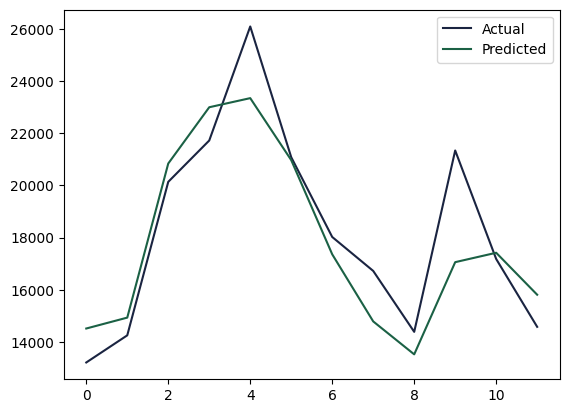

In [122]:
pyplot.plot(y_true, label='Actual')
pyplot.plot(y_pred, label='Predicted')
pyplot.legend()
pyplot.show()